# Generate Dissertation Figures
Generates two publication-quality figures for the dissertation:
1. `fig_training_curves.png` — Fold 5 training curves (loss + F1)
2. `fig_comparison.png` — Method comparison bar chart

**Author:** Luana Marotti | July 2026

In [1]:
# ── Cell 1: Setup ──
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

BASE_DIR  = Path('/mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask')
KFOLD_DIR = BASE_DIR / 'results/unet_training_v3/kfold'
OUT_DIR   = BASE_DIR / 'results/dissertation_figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Style ──
plt.rcParams.update({
    'font.family':     'Times New Roman',
    'font.size':       9,
    'axes.titlesize':  9,
    'axes.labelsize':  9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'figure.dpi':      300,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

BLUE   = '#2a78d6'
GREEN  = '#1baf7a'
ORANGE = '#e07b00'
GRAY   = '#73726c'
LGRAY  = '#c3c2b7'

print(f'Output directory: {OUT_DIR}')

Output directory: /mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask/results/dissertation_figures


In [2]:
# ── Cell 2: Training Curves (Fold 5) ──
# Tries common filename patterns for fold 5 history.
# If not found, prints the available files so you can update the path.

candidate_paths = [
    KFOLD_DIR / 'fold5_history.csv',
    KFOLD_DIR / 'fold5_log.csv',
    KFOLD_DIR / 'fold_5_history.csv',
    BASE_DIR / 'results/unet_training_v3/sweep_lr1e4_test/Ctest_lr1e4_focal_dice_history.csv',
]

csv_path = None
for p in candidate_paths:
    if p.exists():
        csv_path = p
        break

if csv_path is None:
    print('WARNING: No training history CSV found. Using dummy data.')
    print('Available files in kfold dir:')
    print([f.name for f in KFOLD_DIR.glob('*.csv')])
    epochs = list(range(1, 204))
    df = pd.DataFrame({
        'epoch':      epochs,
        'train_loss': [0.51 * (0.97**i) for i in range(len(epochs))],
        'val_loss':   [0.20 * (0.96**i) + 0.037 for i in range(len(epochs))],
        'train_f1':   [min(0.17 + 0.004*i, 0.95) for i in range(len(epochs))],
        'val_f1':     [min(0.16 + 0.0037*i, 0.906) for i in range(len(epochs))],
    })
else:
    df = pd.read_csv(csv_path)
    print(f'Loaded {len(df)} epochs from {csv_path}')
    print(df.columns.tolist())
    print(df.head())

Loaded 203 epochs from /mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask/results/unet_training_v3/kfold/fold5_history.csv
['fold', 'epoch', 'lr', 'train_loss', 'val_loss', 'train_f1', 'val_f1', 'val_prec', 'val_rec']
   fold  epoch       lr  train_loss  val_loss  train_f1  val_f1  val_prec  \
0     5      1  0.00004      0.5173    0.2565    0.1717  0.1653    0.0902   
1     5      2  0.00007      0.4782    0.2367    0.1954  0.1896    0.1049   
2     5      3  0.00010      0.4275    0.1798    0.2774  0.3608    0.2305   
3     5      4  0.00010      0.3889    0.1628    0.4783  0.6488    0.6531   
4     5      5  0.00010      0.3522    0.1509    0.6161  0.6700    0.6685   

   val_rec  
0   0.9916  
1   0.9891  
2   0.8301  
3   0.6446  
4   0.6716  


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

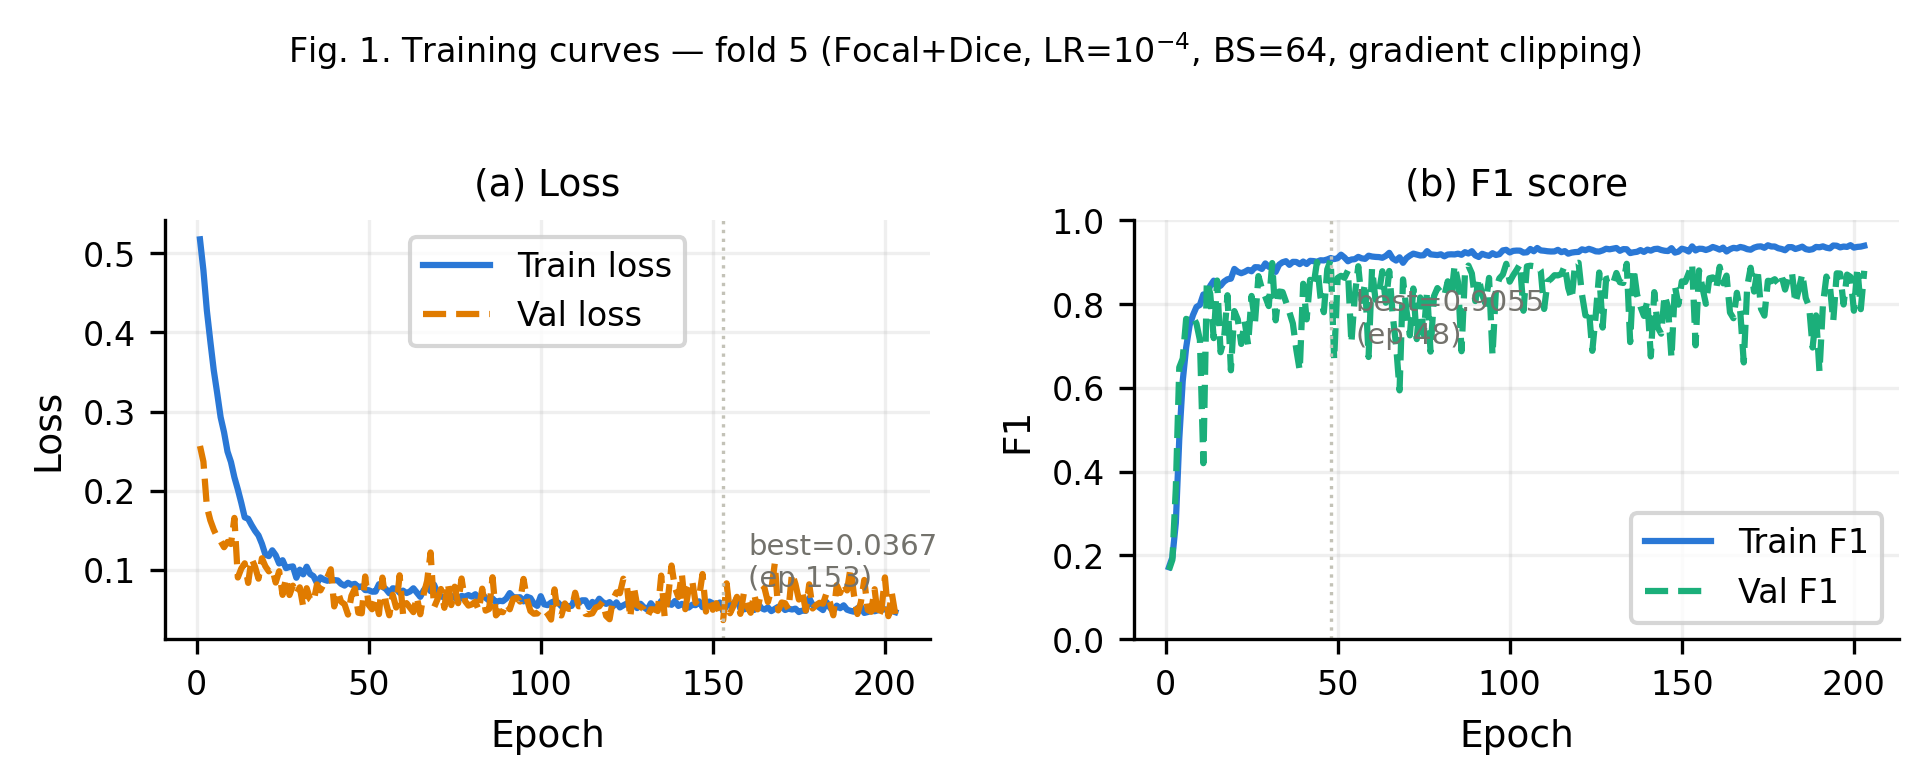

Saved: /mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask/results/dissertation_figures/fig_training_curves.png


In [3]:
# ── Cell 3: Plot Training Curves ──

best_loss_ep = df.loc[df['val_loss'].idxmin(), 'epoch']
best_f1_ep   = df.loc[df['val_f1'].idxmax(), 'epoch']
best_loss    = df['val_loss'].min()
best_f1      = df['val_f1'].max()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6.5, 2.5))
fig.suptitle(
    r'Fig. 1. Training curves — fold 5 (Focal+Dice, LR=$10^{-4}$, BS=64, gradient clipping)',
    fontsize=8, y=1.02
)

ax1.plot(df['epoch'], df['train_loss'], color=BLUE,   lw=1.5, label='Train loss')
ax1.plot(df['epoch'], df['val_loss'],   color=ORANGE, lw=1.5, linestyle='--', label='Val loss')
ax1.axvline(best_loss_ep, color=LGRAY, lw=0.8, linestyle=':')
ax1.annotate(f'best={best_loss:.4f}\n(ep {best_loss_ep})',
             xy=(best_loss_ep, best_loss),
             xytext=(6, 8), textcoords='offset points',
             fontsize=7, color=GRAY)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('(a) Loss'); ax1.legend(); ax1.grid(alpha=0.2)

ax2.plot(df['epoch'], df['train_f1'], color=BLUE,  lw=1.5, label='Train F1')
ax2.plot(df['epoch'], df['val_f1'],   color=GREEN, lw=1.5, linestyle='--', label='Val F1')
ax2.axvline(best_f1_ep, color=LGRAY, lw=0.8, linestyle=':')
ax2.annotate(f'best={best_f1:.4f}\n(ep {best_f1_ep})',
             xy=(best_f1_ep, best_f1),
             xytext=(6, -20), textcoords='offset points',
             fontsize=7, color=GRAY)
ax2.set_ylim(0, 1.0)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('F1')
ax2.set_title('(b) F1 score'); ax2.legend(); ax2.grid(alpha=0.2)

plt.tight_layout()
out1 = OUT_DIR / 'fig_training_curves.png'
plt.savefig(out1, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {out1}')

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

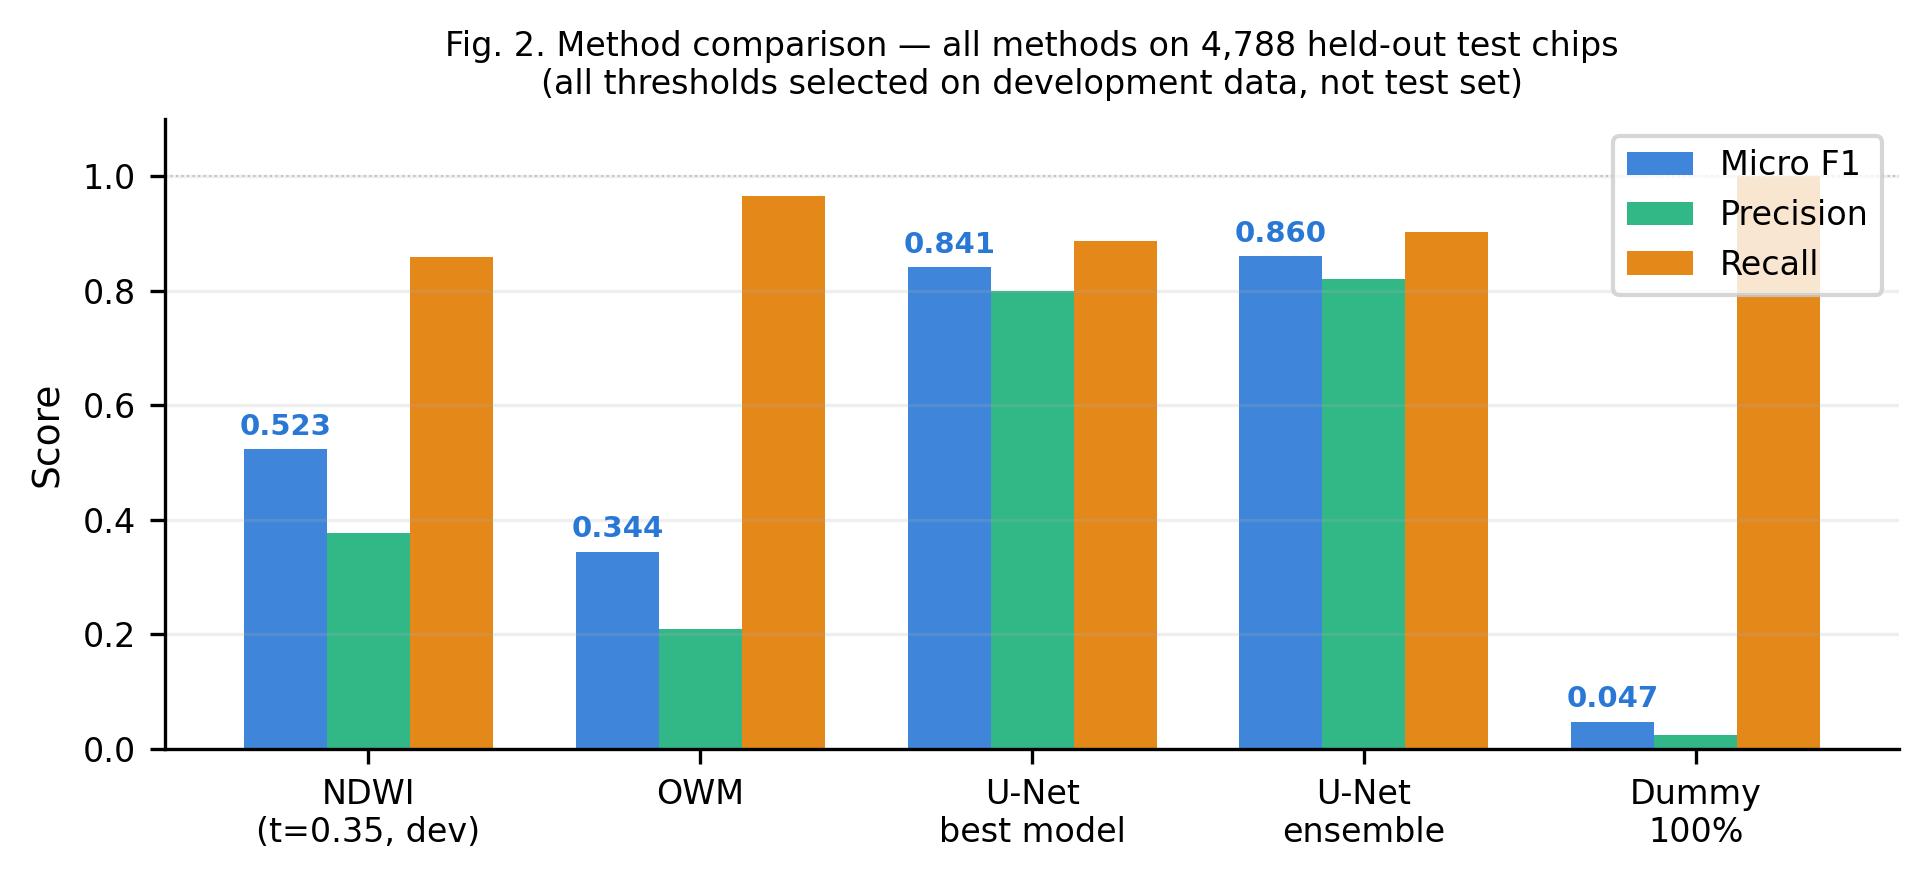

Saved: /mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask/results/dissertation_figures/fig_comparison.png

Both figures saved to: /mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask/results/dissertation_figures


In [4]:
# ── Cell 4: Method Comparison Bar Chart ──
# Final test set results — all thresholds selected on development data.
# NDWI: t=0.35 selected on 51 dev scenes.
# U-Net best model: t=0.25 selected on fold 5 val scenes.
# U-Net ensemble: majority vote, per-fold thresholds from val scenes.

methods = [
    'NDWI\n(t=0.35, dev)',
    'OWM',
    'U-Net\nbest model',
    'U-Net\nensemble',
    'Dummy\n100%',
]
f1   = [0.523,  0.344,  0.8413, 0.8601, 0.047]
prec = [0.376,  0.209,  0.7995, 0.8205, 0.024]
rec  = [0.859,  0.966,  0.8877, 0.9036, 1.000]

x     = np.arange(len(methods))
width = 0.25

fig, ax = plt.subplots(figsize=(6.5, 3.0))
bars_f1   = ax.bar(x - width, f1,   width, label='Micro F1',  color=BLUE,   alpha=0.9)
bars_prec = ax.bar(x,         prec, width, label='Precision', color=GREEN,  alpha=0.9)
bars_rec  = ax.bar(x + width, rec,  width, label='Recall',    color=ORANGE, alpha=0.9)

for bar, val in zip(bars_f1, f1):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
            f'{val:.3f}', ha='center', va='bottom', fontsize=7,
            fontweight='bold', color=BLUE)

ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=8)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_title(
    'Fig. 2. Method comparison — all methods on 4,788 held-out test chips\n'
    '(all thresholds selected on development data, not test set)',
    fontsize=8
)
ax.legend(loc='upper right', fontsize=8)
ax.grid(axis='y', alpha=0.2)
ax.axhline(1.0, color=LGRAY, lw=0.5, linestyle=':')

plt.tight_layout()
out2 = OUT_DIR / 'fig_comparison.png'
plt.savefig(out2, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {out2}')
print(f'\nBoth figures saved to: {OUT_DIR}')